In [1]:
import pandas as pd
import matplotlib.pyplot as plt
X_train = pd.read_csv("../data/preprocessed/X_train.csv")
X_test = pd.read_csv("../data/preprocessed/X_test.csv")

y_train = pd.read_csv("../data/preprocessed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/preprocessed/y_test.csv").values.ravel()

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

models = {
    "Logistic": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:,1]
    y_pred = model.predict(X_test)
    roc = roc_auc_score(y_test, prob)
    print(name, "ROC:", roc)

Logistic ROC: 0.833640919185592
DecisionTree ROC: 0.6621050778843615
RandomForest ROC: 0.8136935668397429
KNN ROC: 0.780577830005539
XGBoost ROC: 0.8054884014681294


### Model Comparison on ROC-AUC

| Model | ROC-AUC Score |
|-------|---------------|
| Logistic Regression | 0.834 |
| Decision Tree       | 0.657 |
| Random Forest       | 0.814 |
| K-Nearest Neighbors | 0.781 |
| XGBoost             | 0.805 |

## Model Performance Summary

The Logistic Regression model achieved:

Accuracy: 80%

ROC-AUC: 0.83

The model shows good ability to distinguish churners from non-churners.
Key factors influencing churn include contract type, tenure, and monthly charges.

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.savefig("X:/Customer_Churn_Prediction/reports/Confusion_matrix.png", bbox_inches="tight")
plt.show()

ValueError: Classification metrics can't handle a mix of binary and continuous targets

### Hyperparameter Tuning using RandomizedSearch

In [4]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### Logistic Regression

In [5]:
param_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}
lr = LogisticRegression()

lr_search = RandomizedSearchCV(
    lr,
    param_distributions=param_lr,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

lr_search.fit(X_train, y_train)

print("Best LR Params:", lr_search.best_params_)
print("Best LR Score:", lr_search.best_score_)

Best LR Params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 100}
Best LR Score: 0.844576352166625


### Random Forest

In [6]:
param_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestClassifier()

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=param_rf,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

print("Best RF Params:", rf_search.best_params_)
print("Best RF Score:", rf_search.best_score_)

Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
Best RF Score: 0.8450565646586281


### XGBoost 

In [7]:
param_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}
xgb = XGBClassifier(eval_metric="logloss")

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_xgb,
    n_iter=20,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Best XGB Params:", xgb_search.best_params_)
print("Best XGB Score:", xgb_search.best_score_)

Best XGB Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best XGB Score: 0.8489472576060638


In [8]:
best_lr = lr_search.best_estimator_
best_rf = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_

In [9]:
from sklearn.metrics import roc_auc_score

models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

for name, model in models.items():
    y_pred = model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, y_pred)
    print(name, "ROC-AUC:", score)

Logistic Regression ROC-AUC: 0.8323803780070508
Random Forest ROC-AUC: 0.8353919584202597
XGBoost ROC-AUC: 0.8419871512804716


### Since XGBoost has the best ROC-AUC score, we can use that model for classification.

In [10]:
import pickle

best_model = best_xgb   

with open("X:\Customer_Churn_Prediction\models\churn_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
    print("Model Exported")

Model Exported


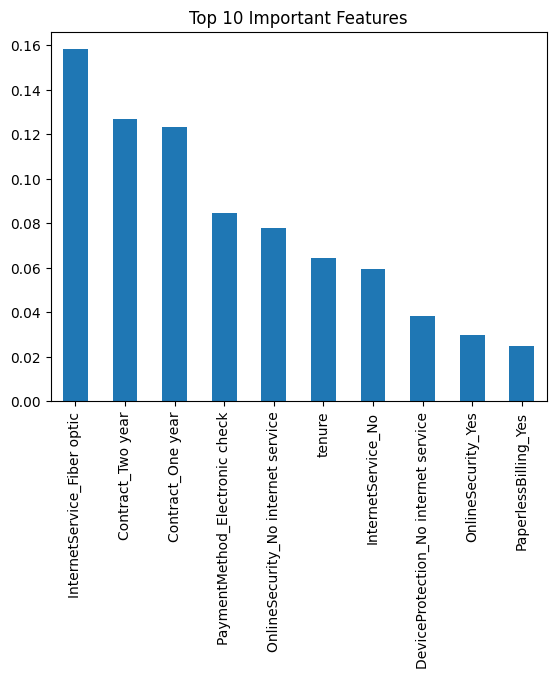

<Figure size 640x480 with 0 Axes>

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

importance = best_model.feature_importances_
features = X_train.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

feat_imp.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.savefig("X:/Customer_Churn_Prediction/reports/feature_importance.png", bbox_inches="tight")
plt.show()

## Feature Importance Summary

### a) InternetService_Fiber optic
Most important feature, strongly influencing the model’s predictions.

### b) Contract_Two year and Contract_One year
Highly important; contract length significantly affects outcomes.

### c) PaymentMethod_Electronic check and OnlineSecurity_No internet service
Contribute notably to the model's decisions.

### d) Tenure
Plays a significant role in prediction accuracy.

### e) InternetService_No, DeviceProtection_No internet service, OnlineSecurity_Yes, PaperlessBilling_Yes
Moderate but meaningful importance in the model.

---

This ranking reveals the key factors driving model performance and provides insight for business strategy.